Here you are assigned as a Data Analyst and Data Scientist to design an analytics framework to see how the credit card users are defaulting.
Here are your tasks regarding this dataset.

List of tasks:

Download data, MySQL & install as localhost on local m/c.

Upload data on MySQL (create/insert/update)

Use Python (SQLAlchemy lib) and connect to localhost. Load the data as dataframe and you will use this dataframe for further processing.

You are expected to do EDA/Exploratory data analysis in Python:

Outlier analysis, 5 point summary, Basic stats & dataframe info, shape etc.

Plots include: Box-plot, pair plot, bar, scatter use Matplotlib & Seaborn. Get one-line summary from each plot.

Data cleaning if needed

Other EDA tasks as usual to understand more about the data

You have to summarize your findings from EDA & propose a further direction

Based on Above analysis; you have to create a solution. It will include one or more of the following. At this stage you will talk & discuss with your mentor to decide on the next part of action

ML model and accuracy improvement.

Based on what you decide before, you need to go ahead & implement 1/2 of the aspects before. Focus on content rather than aesthetics at the moment

For ML model: Why did you create this? How it is to be used? How will it be updated? Optimisation of model, feature selection, accuracy precision & recall to be covered, data imbalances etc. Deliverables: ML model, methodology, variable & model selection process

Case study: Usually happens one time, but you are looking at a scenario where you want to study in detail and propose further strategies to the management and delivery is a report for management

Data dumps: Sample report dumps to be used daily. ex. daily defaulter reports

Finally, you will be presenting to a small panel of judges on what you have done for this project and what more you could have done. Depending on the feedback from the panel, you need to provide possible revisions to your project if needed.

Final Step: U need to prepare the production ready python code and You need to prepare a github repository and push all ur code changes to ur git hub repository


In [ ]:
pip install mysql

In [3]:
pip install mysql-connector-python


Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install pymysql


Note: you may need to restart the kernel to use updated packages.


In [5]:
mydb = mysql.connector.connect(
  host="localhost",               #hostname
  user="root",                   # the user who has privilege to the db
  passwd="Jaanu@0925",               #password for user
  database="ml_practice",               #database name
)

In [6]:
##print(len(df.columns))
#print(df.columns)

##create table with STRUCTURE in MYSQL

CREATE TABLE IF NOT EXISTS `credit_default_raw` (
  `ID` INT,
  `LIMIT_BAL` INT,
  `SEX` TINYINT,
  `EDUCATION` TINYINT,
  `MARRIAGE` TINYINT,
  `AGE` INT,
  `PAY_0` TINYINT,
  `PAY_2` TINYINT,
  `PAY_3` TINYINT,
  `PAY_4` TINYINT,
  `PAY_5` TINYINT,
  `PAY_6` TINYINT,
  `BILL_AMT1` BIGINT,
  `BILL_AMT2` BIGINT,
  `BILL_AMT3` BIGINT,
  `BILL_AMT4` BIGINT,
  `BILL_AMT5` BIGINT,
  `BILL_AMT6` BIGINT,
  `PAY_AMT1` BIGINT,
  `PAY_AMT2` BIGINT,
  `PAY_AMT3` BIGINT,
  `PAY_AMT4` BIGINT,
  `PAY_AMT5` BIGINT,
  `PAY_AMT6` BIGINT,
  `default payment next month` TINYINT
);


#to see databases;
mysql> show databases;
#use database
mysql>use database(ml_practice);
#to see tables
mysql> show tables;
credit_default_raw(created new table in DB)

In [7]:
#insert data into the table credit_default_raw by using python
import pandas as pd
import mysql.connector



# load CSV correctly 
df1 = pd.read_csv(r"C:\Users\life\Downloads\Practice_Python\default of credit card clients.csv")

# drop unnamed index column if it exists
if "Unnamed: 0" in df1.columns:
    df1 = df1.drop(columns=["Unnamed: 0"])

print("Columns in CSV:", df1.columns)
print("Shape:", df1.shape)  # should be (30000, 26)

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="Jaanu@0925",
    database="ML_Practice"
)
cursor = conn.cursor()
##if we run this loaad csv after restaring kernel, again new set of data is added into the table(duplication of rows)
## to avoid duplication of rows , need to add this
cursor.execute("TRUNCATE TABLE credit_default_raw")


cols = ",".join([f"`{c}`" for c in df1.columns])
placeholders = ",".join(["%s"] * len(df1.columns))

sql = f"INSERT INTO credit_default_raw ({cols}) VALUES ({placeholders})"

for _, row in df1.iterrows():
    cursor.execute(sql, tuple(row))
conn.commit()
conn.close()


Columns in CSV: Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='object')
Shape: (30000, 25)


In [8]:
df1.head()


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [9]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

In [10]:
#defining query to see all the database available in the mysql server
query='show tables'

In [11]:
print(mydb)

In [12]:
#define cursor object
cursor=mydb.cursor()

In [13]:
#defining query to see all the database available in the mysql server
query='show tables'

In [14]:
#execute query
cursor.execute(query)

In [15]:
for i in cursor:
    print(i)

('credit_default_raw',)


In [16]:
#fetch all databases
result=(cursor.fetchall())

In [17]:
#iterate through all data bases
for i in result:
    print(i)

In [18]:
#define the query to navigate to the table we want
query = "SELECT * FROM credit_default_raw WHERE ID=20"
cursor.execute(query)

# consume result
result = cursor.fetchall()   # or cursor.fetchone()
print(result)

[(20, 180000, 2, 1, 2, 29, 1, -2, -2, -2, -2, -2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0)]


In [19]:
for i in cursor:
    print(i)

In [20]:
query='Select * from credit_default_raw'
data_frame=pd.read_sql(query,mydb)
print(data_frame)

C:\Users\life\AppData\Local\Temp\ipykernel_12320\1535728332.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  data_frame=pd.read_sql(query,mydb)


          ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  \
0          1      20000    2          2         1   24      2      2     -1   
1          2     120000    2          2         2   26     -1      2      0   
2          3      90000    2          2         2   34      0      0      0   
3          4      50000    2          2         1   37      0      0      0   
4          5      50000    1          2         1   57     -1      0     -1   
...      ...        ...  ...        ...       ...  ...    ...    ...    ...   
29995  29996     220000    1          3         1   39      0      0      0   
29996  29997     150000    1          3         2   43     -1     -1     -1   
29997  29998      30000    1          2         2   37      4      3      2   
29998  29999      80000    1          3         1   41      1     -1      0   
29999  30000      50000    1          2         1   46      0      0      0   

       PAY_4  ...  BILL_AMT4  BILL_AMT5  BILL_AMT6 

In [21]:
df=pd.read_sql_query("select * from credit_default_raw",mydb)

C:\Users\life\AppData\Local\Temp\ipykernel_12320\4213540584.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df=pd.read_sql_query("select * from credit_default_raw",mydb)


In [22]:
df

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,220000,1,3,1,39,0,0,0,0,...,88004,31237,15980,8500,20000,5003,3047,5000,1000,0
29996,29997,150000,1,3,2,43,-1,-1,-1,-1,...,8979,5190,0,1837,3526,8998,129,0,0,0
29997,29998,30000,1,2,2,37,4,3,2,-1,...,20878,20582,19357,0,0,22000,4200,2000,3100,1
29998,29999,80000,1,3,1,41,1,-1,0,0,...,52774,11855,48944,85900,3409,1178,1926,52964,1804,1


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

In [24]:
df.shape

(30000, 25)

In [25]:
columns = df.columns
for i in columns:
 print(i)

ID
LIMIT_BAL
SEX
EDUCATION
MARRIAGE
AGE
PAY_0
PAY_2
PAY_3
PAY_4
PAY_5
PAY_6
BILL_AMT1
BILL_AMT2
BILL_AMT3
BILL_AMT4
BILL_AMT5
BILL_AMT6
PAY_AMT1
PAY_AMT2
PAY_AMT3
PAY_AMT4
PAY_AMT5
PAY_AMT6
default payment next month


In [26]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


In [27]:
data=df.to_csv("data.csv",index=False)

In [28]:
data=pd.read_csv("data.csv")

In [29]:
data

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,220000,1,3,1,39,0,0,0,0,...,88004,31237,15980,8500,20000,5003,3047,5000,1000,0
29996,29997,150000,1,3,2,43,-1,-1,-1,-1,...,8979,5190,0,1837,3526,8998,129,0,0,0
29997,29998,30000,1,2,2,37,4,3,2,-1,...,20878,20582,19357,0,0,22000,4200,2000,3100,1
29998,29999,80000,1,3,1,41,1,-1,0,0,...,52774,11855,48944,85900,3409,1178,1926,52964,1804,1


In [30]:
data.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [31]:
##Plotting BAR PLOTS

In [32]:
data.LIMIT_BAL.value_counts(ascending=False)

LIMIT_BAL
50000      3365
20000      1976
30000      1610
80000      1567
200000     1528
           ... 
800000        2
1000000       1
327680        1
760000        1
690000        1
Name: count, Length: 81, dtype: int64

<Axes: title={'center': 'unique blalances'}, xlabel='LIMIT_BAL'>

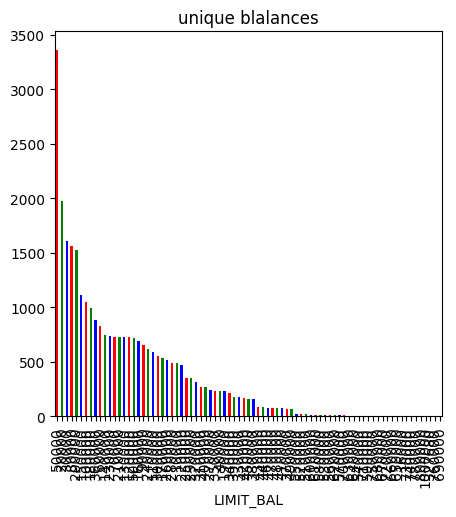

In [33]:
data['LIMIT_BAL'].value_counts(ascending=False).plot(kind='bar',color=['red','green','blue'],title='unique blalances',figsize=(5,5))

In [34]:
data['SEX'].value_counts()

SEX
2    18112
1    11888
Name: count, dtype: int64

<Axes: title={'center': 'ratio of sex'}, xlabel='SEX'>

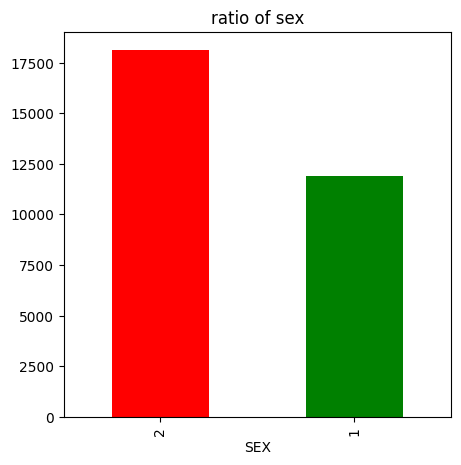

In [35]:
data['SEX'].value_counts().plot(kind='bar',color=['red','green'],figsize=(5,5),title='ratio of sex')

In [36]:
data['EDUCATION'].value_counts()

EDUCATION
2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14
Name: count, dtype: int64

In [37]:
data['MARRIAGE'].value_counts()

MARRIAGE
2    15964
1    13659
3      323
0       54
Name: count, dtype: int64

<Axes: title={'center': 'marriage'}, xlabel='MARRIAGE'>

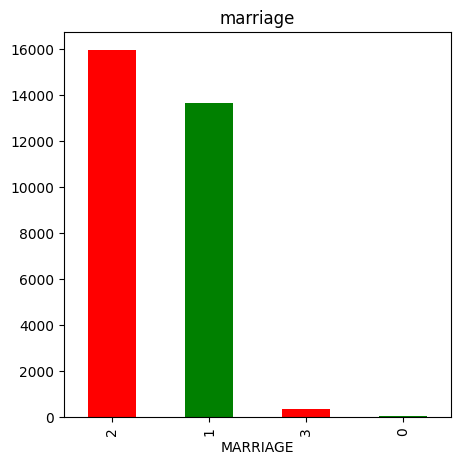

In [38]:
data["MARRIAGE"].value_counts().plot(kind='bar',color=['r','g'],title='marriage',figsize=(5,5))

In [39]:
#finding duplicate data
data['ID'].nunique()

30000

In [40]:
total_rows = len(data)
unique_ids = data['ID'].nunique()
duplicates = total_rows - unique_ids

print(f"Total rows: {total_rows}")
print(f"Unique IDs: {unique_ids}")
print(f"Duplicate IDs: {duplicates}")

Total rows: 30000
Unique IDs: 30000
Duplicate IDs: 0


In [41]:
#all the values in Id number are unique values so
#they are not much important in model building.

In [42]:
## Finding null values

In [43]:
data.isnull().sum()

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default payment next month    0
dtype: int64

In [44]:
#sns.pairplot(data)

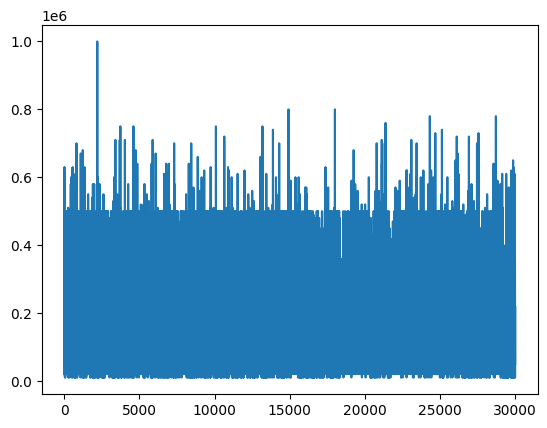

In [45]:
plt.plot(data["LIMIT_BAL"])

In [46]:
##BOX PLOT

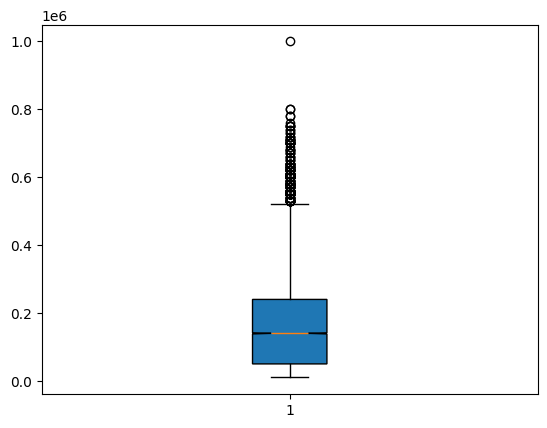

In [47]:
box_plot_data=data['LIMIT_BAL']
plt.boxplot(box_plot_data,notch='True',patch_artist=True)
plt.show()

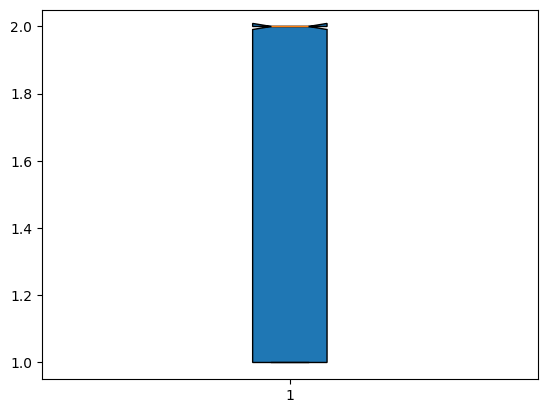

In [48]:
box_plot_data=data['SEX']
plt.boxplot(box_plot_data,notch='True',patch_artist=True)
plt.show()

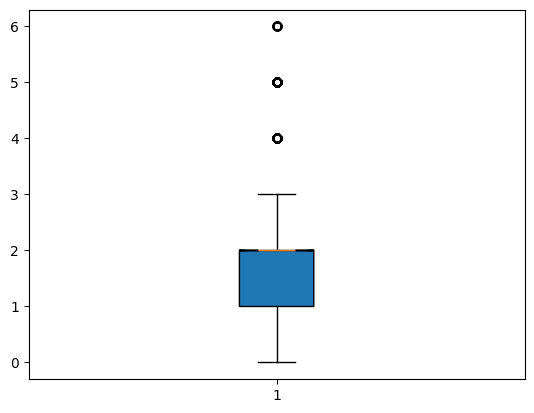

In [49]:
box_plot_data=data['EDUCATION']
plt.boxplot(box_plot_data,notch='True',patch_artist=True)
plt.show()

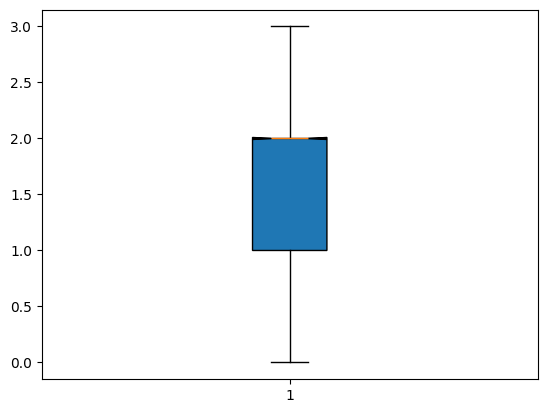

In [50]:
box_plot_data=data['MARRIAGE']
plt.boxplot(box_plot_data,notch='True',patch_artist=True)
plt.show()

In [51]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


Finding Outliers
#Here we are finding outliers using boxplot

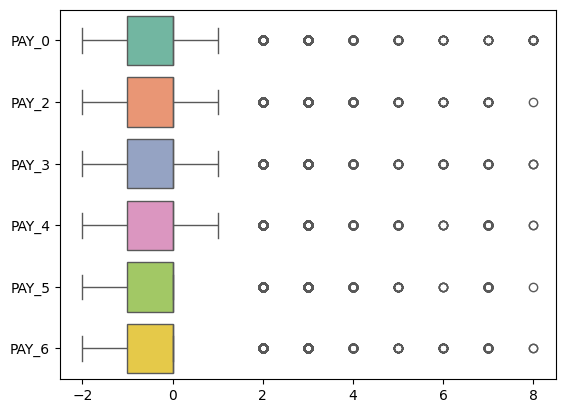

In [52]:
#df.describe()

df_1 = data[['PAY_0', 'PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']]
df_2 = data[['BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6']]
df_3 = data[['PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6']]

ax = sns.boxplot(data=df_1, orient="h", palette="Set2")

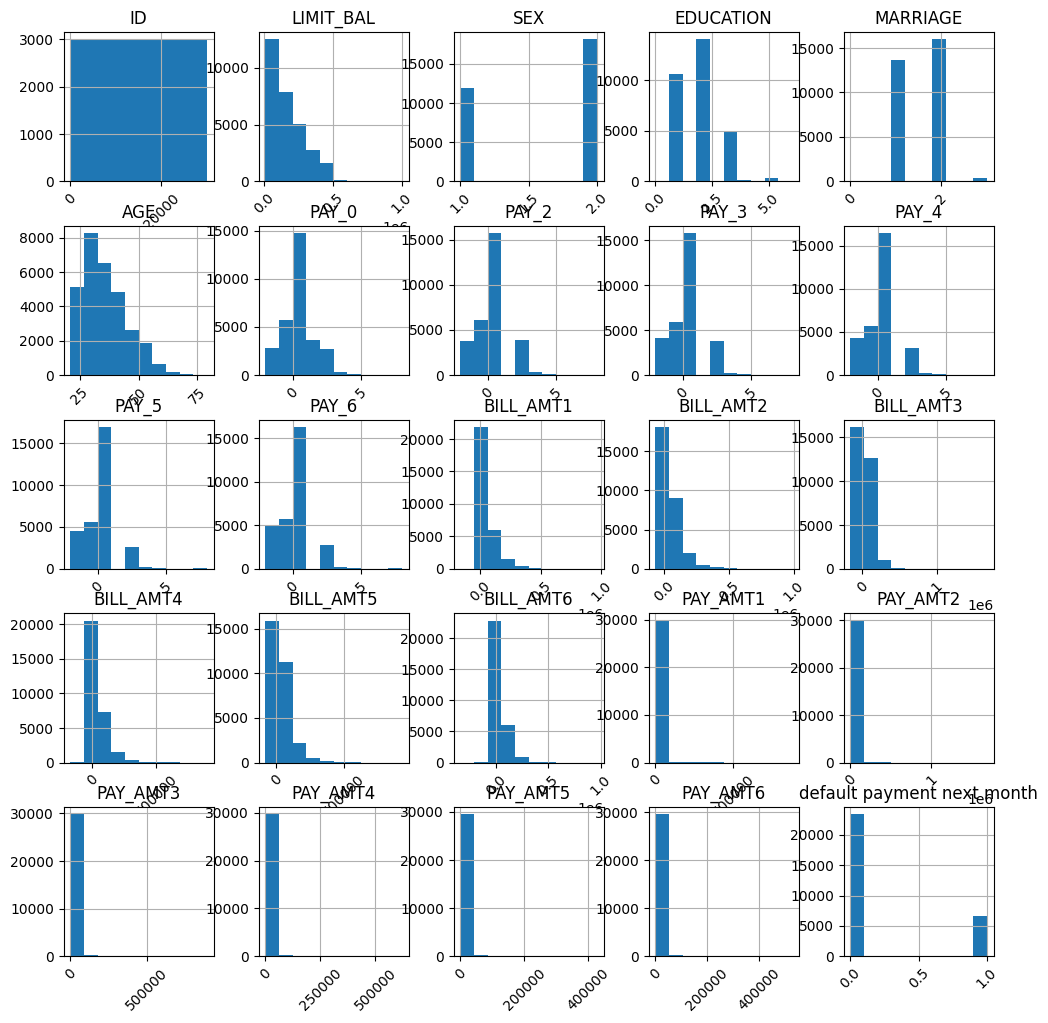

In [53]:
#Histogram
data.hist(figsize=(12,12), xrot=45)
plt.show()

In [54]:
X=df.drop('default payment next month',axis=1)
y=df['default payment next month']

In [55]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=0)

X_train.shape, X_test.shape
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (21000, 24)
Test shape: (9000, 24)


In [56]:
### First we build the model with raw features


In [57]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import BaggingClassifier

In [58]:
 X_train, X_test, y_train, y_test, = train_test_split(X,
                                                  y,
                                                  test_size = .3,
                                                  random_state=0)
clf = LogisticRegression(max_iter=500, solver='saga')  # good for large datasets
trained_model = clf.fit(X_train, y_train)
trained_model.fit(X_train, y_train)
y_pred = trained_model.predict(X_test)

Train_Accuracy= accuracy_score(y_train, trained_model.predict(X_train))
Test_Accuracy= accuracy_score(y_test, y_pred)
Confusion_Matrix= confusion_matrix(y_test, y_pred)

In [59]:
print("Train accuracy:",Train_Accuracy)
print("Test accuracy:",Test_Accuracy)
print(Confusion_Matrix)
print(accuracy_score(y_test, y_pred))

Train accuracy: 0.7762380952380953
Test accuracy: 0.7845555555555556
[[7060    0]
 [1939    1]]
0.7845555555555556


In [60]:
#Our model showed a accuracy of 77 percent without any outlier treatment .
#In order to improve our model we can check for correlation of features

In [61]:
#checking correlation
X_train.corr()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
ID,1.000000,0.030391,0.016759,0.034518,-0.033774,0.022768,-0.030399,-0.012601,-0.022912,-0.007375,...,0.025996,0.041812,0.016636,0.016038,0.016326,0.010308,0.043374,0.008823,-0.004063,0.005704
LIMIT_BAL,0.030391,1.000000,0.026729,-0.215178,-0.110903,0.147624,-0.268271,-0.295177,-0.285572,-0.267489,...,0.281839,0.288848,0.290803,0.285093,0.188021,0.178122,0.202081,0.200656,0.215698,0.221848
SEX,0.016759,0.026729,1.000000,0.014225,-0.034579,-0.084932,-0.065389,-0.075153,-0.070457,-0.060587,...,-0.026960,-0.025236,-0.018538,-0.018343,-0.003899,-0.002292,-0.011307,-0.001476,-0.002539,-0.003660
EDUCATION,0.034518,-0.215178,0.014225,1.000000,-0.142816,0.176723,0.107096,0.123027,0.114751,0.106927,...,0.012254,0.000228,-0.007935,-0.009493,-0.036566,-0.036294,-0.037621,-0.043597,-0.042287,-0.036042
MARRIAGE,-0.033774,-0.110903,-0.034579,-0.142816,1.000000,-0.412603,0.016384,0.018425,0.027696,0.031648,...,-0.029844,-0.027946,-0.030112,-0.025313,-0.005654,-0.004304,-0.000490,-0.009689,-0.000616,-0.006177
AGE,0.022768,0.147624,-0.084932,0.176723,-0.412603,1.000000,-0.036249,-0.049272,-0.053959,-0.053472,...,0.053196,0.052643,0.051006,0.048441,0.025856,0.016954,0.033150,0.015962,0.020478,0.020046
PAY_0,-0.030399,-0.268271,-0.065389,0.107096,0.016384,-0.036249,1.000000,0.678245,0.581280,0.538772,...,0.179444,0.180613,0.181751,0.178323,-0.077774,-0.073797,-0.076510,-0.065187,-0.055092,-0.059660
PAY_2,-0.012601,-0.295177,-0.075153,0.123027,0.018425,-0.049272,0.678245,1.000000,0.763802,0.659024,...,0.221788,0.222653,0.221372,0.219875,-0.082482,-0.060762,-0.060202,-0.049971,-0.035097,-0.039727
PAY_3,-0.022912,-0.285572,-0.070457,0.114751,0.027696,-0.053959,0.581280,0.763802,1.000000,0.780698,...,0.224452,0.225280,0.223147,0.219374,0.000249,-0.065734,-0.056435,-0.048793,-0.035492,-0.035782
PAY_4,-0.007375,-0.267489,-0.060587,0.106927,0.031648,-0.053472,0.538772,0.659024,0.780698,1.000000,...,0.242585,0.245452,0.242168,0.238238,-0.009191,-0.002280,-0.070746,-0.047106,-0.032781,-0.024157


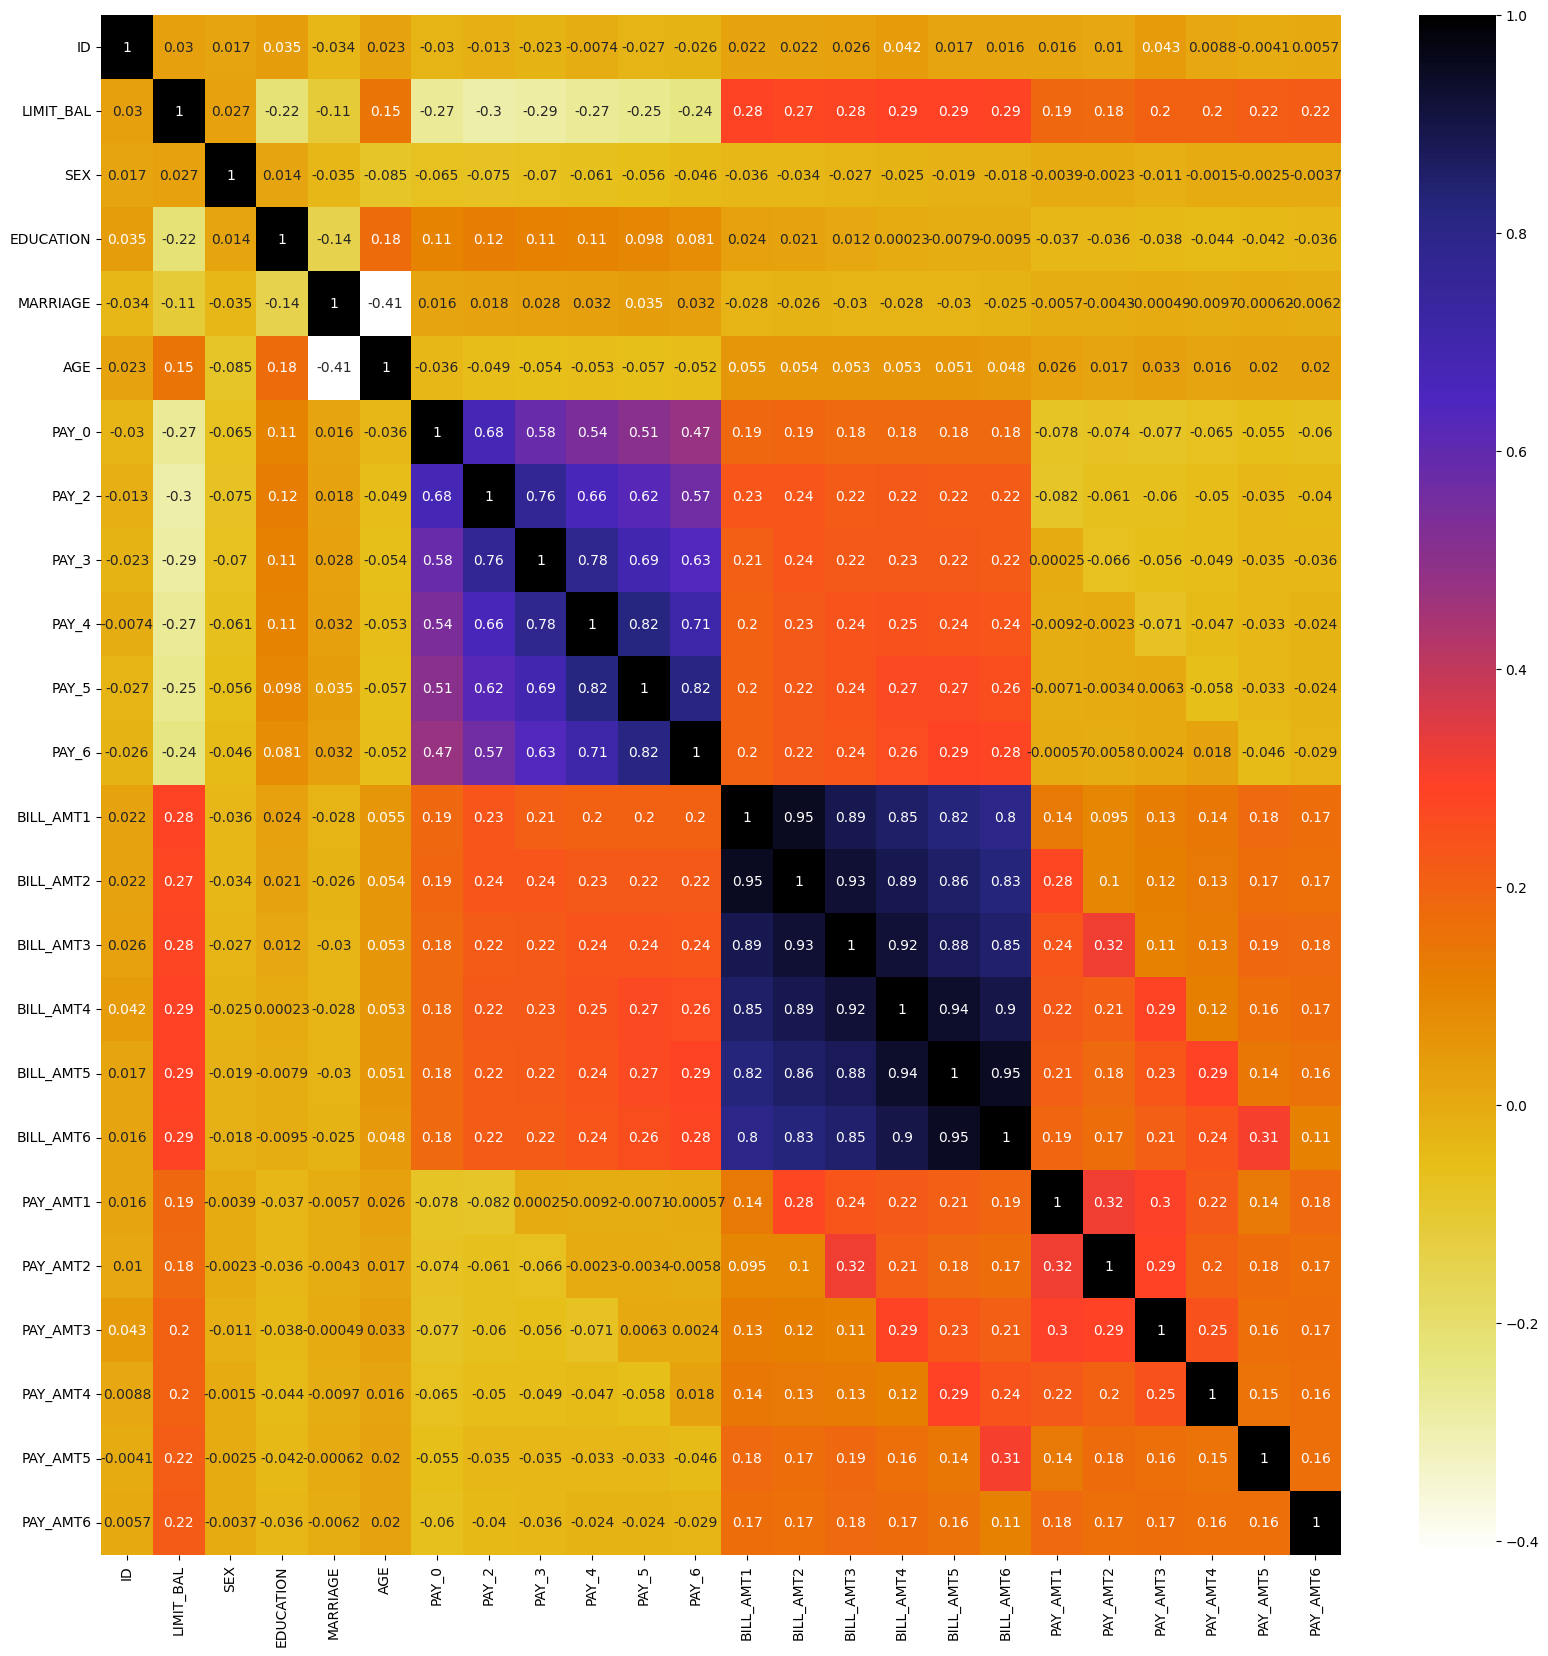

In [62]:
import seaborn as sns
#Using Pearson Correlation
plt.figure(figsize=(20,20))
cor = X_train.corr()
sns.heatmap(cor, annot=True, cmap=plt.cm.CMRmap_r)
plt.show()

In [63]:
# with the following function we can select highly correlated features
# it will remove the first feature that is correlated with anything other feature

def correlation(dataset, threshold):
    col_corr = set()  # Set of all the names of correlated columns
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold: # we are interested in absolute coeff value
                colname = corr_matrix.columns[i]  # getting the name of column
                col_corr.add(colname)
    return col_corr

In [64]:
corr_features = correlation(X_train, 0.8)
len(set(corr_features))

7

In [65]:
corr_features

{'BILL_AMT2',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_5',
 'PAY_6'}

In [66]:
data1=data.drop(corr_features,axis=1)

In [67]:
X=data1.drop('default payment next month',axis=1)
y=data1['default payment next month']

In [68]:
X.shape

(30000, 17)

In [69]:
y.shape


(30000,)

In [130]:
 X_train, X_test, y_train, y_test, = train_test_split(X,
                                                  y,
                                                  test_size = .15,
                                                  random_state=1)
clf = LogisticRegression(random_state = 0)
trained_model = clf.fit(X_train, y_train)
trained_model.fit(X_train, y_train)
y_pred = trained_model.predict(X_test)

Train_Accuracy= accuracy_score(y_train, trained_model.predict(X_train))
Test_Accuracy= accuracy_score(y_test, y_pred)
Confusion_Matrix= confusion_matrix(y_test, y_pred)

C:\Users\life\anaconda3\envs\python_39\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\life\anaconda3\envs\python_39\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#l

In [131]:
print("Train accuracy:",Train_Accuracy)
print("Test accuracy:",Test_Accuracy)
print(Confusion_Matrix)
print(accuracy_score(y_test, y_pred))

Train accuracy: 0.7788627450980392
Test accuracy: 0.7784444444444445
[[3503    0]
 [ 997    0]]
0.7784444444444445


In [72]:
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_test, y_pred)
print(cm)
accuracy_score(y_test, y_pred)

[[7000    0]
 [2000    0]]


0.7777777777777778

In [73]:
## Standaradistion
#AS we have different scales of data we can convert our data using standar scalar.

In [74]:
X=data.drop('default payment next month',axis=1)
y=data['default payment next month']

In [132]:
 X_train, X_test, y_train, y_test, = train_test_split(X,
                                                  y,
                                                  test_size = .15,
                                                  random_state=0)

In [133]:
from sklearn import preprocessing
sc= preprocessing.StandardScaler()
scaler_train=sc.fit_transform(X_train)
scaler_train

array([[ 0.20700646, -0.90748654, -1.22815358, ..., -0.24250691,
        -0.1852927 , -0.29473885],
       [-0.50123933, -0.90748654, -1.22815358, ..., -0.26631859,
        -0.27352764, -0.25885211],
       [-0.19419436, -0.52140242, -1.22815358, ...,  0.07315707,
        -0.15251597, -0.23840174],
       ...,
       [-0.59354898, -0.28975195,  0.81423042, ..., -0.04781138,
        -0.3163996 , -0.01305328],
       [-0.48346972, -0.90748654,  0.81423042, ..., -0.24518095,
        -0.25084615, -0.2665703 ],
       [-1.41429716, -0.21253512,  0.81423042, ..., -0.18151334,
        -0.17218201, -0.18206462]])

In [134]:
scaler_test=sc.transform(X_test)
scaler_test

array([[-0.78047602, -1.13913701, -1.22815358, ..., -0.20698038,
        -0.3163996 , -0.25845775],
       [-0.48404666, -1.13913701,  0.81423042, ..., -0.30884855,
        -0.25084615, -0.29473885],
       [-0.67224296,  0.48241629,  0.81423042, ..., -0.30884855,
        -0.3163996 , -0.29473885],
       ...,
       [ 1.14244937, -0.67583607, -1.22815358, ..., -0.30547416,
        -0.10479306, -0.29473885],
       [-1.22794705,  1.56345183, -1.22815358, ..., -0.30884855,
        -0.0903713 , -0.29473885],
       [-1.54999234, -0.90748654, -1.22815358, ..., -0.24167923,
        -0.24743737, -0.23716232]])

In [135]:
clf = LogisticRegression(random_state = 0)
trained_model = clf.fit(scaler_train, y_train)
trained_model.fit(scaler_train, y_train)
y_pred = trained_model.predict(scaler_test)

Train_Accuracy= accuracy_score(y_train, trained_model.predict(scaler_train))
Test_Accuracy= accuracy_score(y_test, y_pred)
Confusion_Matrix= confusion_matrix(y_test, y_pred)

In [136]:
print("Train accuracy:",Train_Accuracy)
print("Test accuracy:",Test_Accuracy)
print(Confusion_Matrix)
print(accuracy_score(y_test, y_pred))

Train accuracy: 0.8088235294117647
Test accuracy: 0.8175555555555556
[[3452   77]
 [ 744  227]]
0.8175555555555556


In [137]:
##DecisionTreeClassifier
clf = DecisionTreeClassifier(random_state=0)

# Train
trained_model = clf.fit(scaler_train, y_train)

# Predict
y_pred = trained_model.predict(scaler_test)

# Evaluation
Train_Accuracy = accuracy_score(y_train, trained_model.predict(scaler_train))
Test_Accuracy = accuracy_score(y_test, y_pred)
Confusion_Matrix = confusion_matrix(y_test, y_pred)



In [138]:
print("Train Accuracy:", Train_Accuracy)
print("Test Accuracy:", Test_Accuracy)
print("Confusion Matrix:\n", Confusion_Matrix)


Train Accuracy: 1.0
Test Accuracy: 0.7257777777777777
Confusion Matrix:
 [[2853  676]
 [ 558  413]]


In [139]:
##KNeighborsClassifier

clf = KNeighborsClassifier(n_neighbors=5)  # you can tune n_neighbors
trained_model = clf.fit(scaler_train, y_train)

y_pred = trained_model.predict(scaler_test)

from sklearn.metrics import accuracy_score, confusion_matrix
Train_Accuracy = accuracy_score(y_train, trained_model.predict(scaler_train))
Test_Accuracy = accuracy_score(y_test, y_pred)
Confusion_Matrix = confusion_matrix(y_test, y_pred)



In [140]:
print("Train Accuracy:", Train_Accuracy)
print("Test Accuracy:", Test_Accuracy)
print("Confusion Matrix:\n", Confusion_Matrix)

Train Accuracy: 0.8422352941176471
Test Accuracy: 0.7962222222222223
Confusion Matrix:
 [[3250  279]
 [ 638  333]]


In [141]:
##RandomForestClassifier

# Random Forest
clf = RandomForestClassifier(n_estimators=100, random_state=0)  # 100 trees
trained_model = clf.fit(scaler_train, y_train)

# Predictions
y_pred = trained_model.predict(scaler_test)

# Accuracy and confusion matrix
Train_Accuracy = accuracy_score(y_train, trained_model.predict(scaler_train))
Test_Accuracy = accuracy_score(y_test, y_pred)
Confusion_Matrix = confusion_matrix(y_test, y_pred)




In [142]:
print("Train Accuracy:", Train_Accuracy)
print("Test Accuracy:", Test_Accuracy)
print("Confusion Matrix:\n", Confusion_Matrix)

Train Accuracy: 0.9999607843137255
Test Accuracy: 0.826
Confusion Matrix:
 [[3354  175]
 [ 608  363]]


In [144]:
##BaggingClassifier
clf = BaggingClassifier(n_estimators=50, random_state=0)  # 100 trees(tried 100 )
trained_model = clf.fit(scaler_train, y_train)

# Predictions
y_pred = trained_model.predict(scaler_test)

# Accuracy and confusion matrix
Train_Accuracy = accuracy_score(y_train, trained_model.predict(scaler_train))
Test_Accuracy = accuracy_score(y_test, y_pred)
Confusion_Matrix = confusion_matrix(y_test, y_pred)


In [145]:
print("Train Accuracy:", Train_Accuracy)
print("Test Accuracy:", Test_Accuracy)
print("Confusion Matrix:\n", Confusion_Matrix)

Train Accuracy: 0.9993333333333333
Test Accuracy: 0.8177777777777778
Confusion Matrix:
 [[3330  199]
 [ 621  350]]


In [146]:
##GaussianNB
# Gaussian Naive Bayes
clf = GaussianNB()
trained_model = clf.fit(scaler_train, y_train)

# Predictions
y_pred = trained_model.predict(scaler_test)

# Accuracy and confusion matrix
Train_Accuracy = accuracy_score(y_train, trained_model.predict(scaler_train))
Test_Accuracy = accuracy_score(y_test, y_pred)
Confusion_Matrix = confusion_matrix(y_test, y_pred)


In [147]:
print("Train Accuracy:", Train_Accuracy)
print("Test Accuracy:", Test_Accuracy)
print("Confusion Matrix:\n", Confusion_Matrix)

Train Accuracy: 0.7250196078431372
Test Accuracy: 0.7215555555555555
Confusion Matrix:
 [[2639  890]
 [ 363  608]]
